In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Split Integrity Audit Notebook

This notebook audits split integrity for the CLEAN pipeline.

It generates figures and summary tables for presentation and CI.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from pathlib import Path

# Load features and split manifest
features = pd.read_parquet("artifacts/clean_pipeline/features.parquet")
manifest = json.load(open("artifacts/clean_pipeline/clean_split_manifest.json"))

## 1. Split composition per dataset (stacked bar chart)

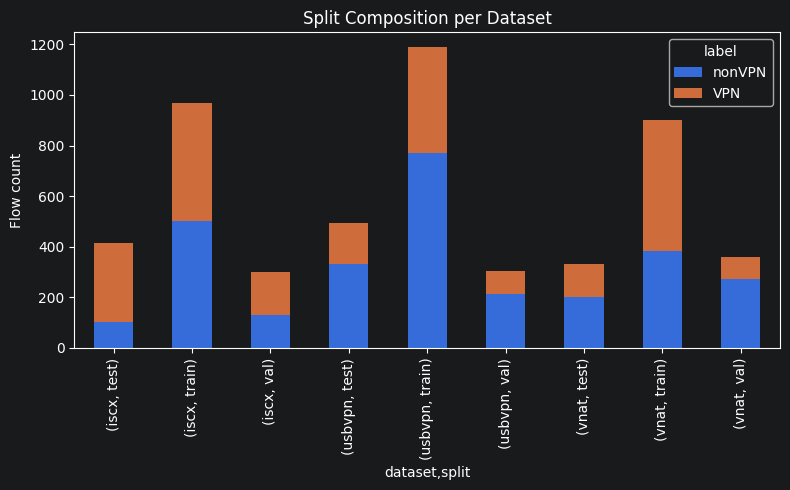

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

split_counts = (
    features
    .groupby(["dataset", "split", "label"])
    .size()
    .unstack(fill_value=0)
)

split_counts = split_counts.rename(columns={0: "nonVPN", 1: "VPN"})

split_counts[["nonVPN", "VPN"]].plot(
    kind="bar",
    stacked=True,
    ax=ax
)

plt.title("Split Composition per Dataset")
plt.ylabel("Flow count")
plt.tight_layout()

plt.savefig("figures/validation/split_composition_per_dataset.png")
plt.show()

## 2. Capture size distribution (boxplot/violin plot)

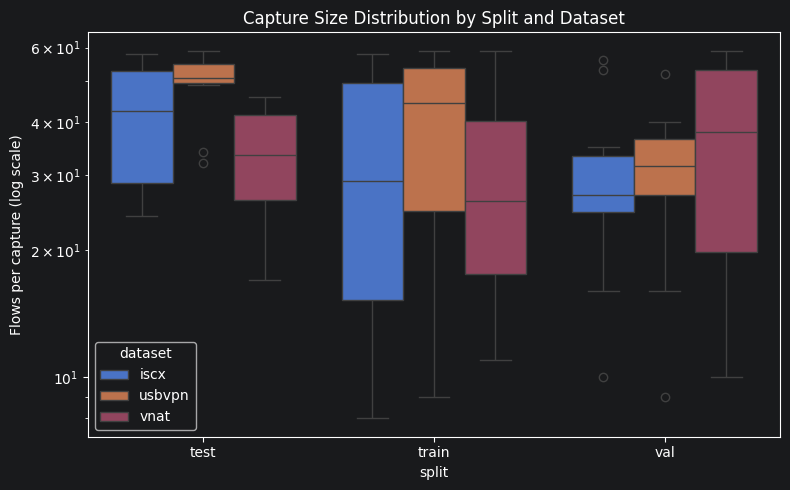

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

cap_sizes = (
    features
    .groupby(["dataset", "split", "capture_id"])
    .size()
    .reset_index(name="n_flows")
)

sns.boxplot(
    data=cap_sizes,
    x="split",
    y="n_flows",
    hue="dataset",
    ax=ax
)

ax.set_yscale("log")

plt.title("Capture Size Distribution by Split and Dataset")
plt.ylabel("Flows per capture (log scale)")
plt.tight_layout()

plt.savefig("figures/validation/capture_size_distribution.png")
plt.show()

## 3. Split constraint violations by seed (bar/line chart)

In [5]:
# Example: load diagnostics from multiple seeds if available

import glob

violation_counts = []

for path in glob.glob("artifacts/validation/diagnostics_seed_*.json"):
    with open(path) as f:
        diag = json.load(f)

    seed = int(path.split("_")[-1].split(".")[0])
    n_viol = len(diag.get("constraint_violations", []))

    violation_counts.append(
        {
            "seed": seed,
            "violations": n_viol
        }
    )

if violation_counts:
    df_viol = pd.DataFrame(violation_counts)

    fig, ax = plt.subplots(figsize=(8, 4))

    sns.barplot(
        data=df_viol,
        x="seed",
        y="violations",
        ax=ax
    )

    plt.title("Split Constraint Violations by Seed")
    plt.ylabel("Number of violations")
    plt.tight_layout()

    plt.savefig("figures/validation/split_constraint_violations_by_seed.png")
    plt.show()

else:
    print("No diagnostics found for multiple seeds.")

No diagnostics found for multiple seeds.


## 4. Save split integrity summary (CSV/JSON)

In [6]:
summary = []

for ds in manifest["per_dataset_split"]:
    for split, stats in manifest["per_dataset_split"][ds].items():
        summary.append(
            {
                "dataset": ds,
                "split": split,
                **stats
            }
        )

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    "artifacts/validation/split_integrity_summary.csv",
    index=False
)

summary_df.to_json(
    "artifacts/validation/split_integrity_summary.json",
    orient="records",
    indent=2
)

summary_df.head()

,dataset,split,n_flows,n_captures,n_vpn,n_nonvpn
0,iscx,train,967,30,465,502
1,iscx,val,302,10,173,129
2,iscx,test,416,10,312,104
3,usbvpn,train,1188,30,418,770
4,usbvpn,val,306,10,91,215
